<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ...agreuge otras librerías si lo considera relevante
import zipfile # se importa zipfile para leer los archivos sin descomprimir
# Para los entrenamientos y modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


_A pesar de las columnas pedidas para extracción, se agregarán algunas columnas en los datasets de expediciones y montañistas para facilitar el merge final de los datasets._

In [73]:
# 1. Montañas

with zipfile.ZipFile('Himalayan+Expeditions.zip') as z:
    with z.open('peaks_with_exp.csv') as f:
        df_m = pd.read_csv(f)

df_m.head()

,peakid,pkname,pkname2,location,heightm,heightf,himal,region,open,unlisted,...,pyear,pseason,pmonth,pday,pexpid,pcountry,psummiters,psmtnote,failed_exp,success_exp
0,ACHN,Aichyn,"Aychin, Ashvin",Chandi Himal (SW of Changwathang),6055,19865,Nalakankar/Chandi/Changla,Kanjiroba-Far West,True,False,...,2015.0,Autumn,Sep,3.0,ACHN15301,Japan,"Hiroki Senda, et al",NaN,1,2
1,AMAD,Ama Dablam,Amai Dablang,Khumbu Himal,6814,22356,Khumbu,Khumbu-Rolwaling-Makalu,True,False,...,1961.0,Spring,Mar,13.0,AMAD61101,"New Zealand, USA, UK","Mike Gill, Wally Romanes, Barry Bishop, Michae...",NaN,453,1123
2,AMOT,Amotsang,Amatson,Damodar Himal (NW of Pokharhan),6393,20974,Damodar,Annapurna-Damodar-Peri,True,False,...,2019.0,Autumn,Oct,24.0,AMOT19301,Germany,Jost Kobusch,Possibly climbed earlier,2,1
3,AMPG,Amphu Gyabjen,Amphu Gyabien,Khumbu Himal (N of Ama Dablam),5630,18471,Khumbu,Khumbu-Rolwaling-Makalu,True,False,...,1953.0,Spring,Apr,11.0,AMPG53101,UK,"John Hunt, Tom Bourdillon",NaN,1,3
4,AMPH,Amphu I,NaN,"Khumbu Himal (E of Amphu Laptsa, W of Baruntse)",6740,22113,Khumbu,Khumbu-Rolwaling-Makalu,True,False,...,2013.0,Autumn,Oct,9.0,AMPH13301,S Korea,"An Chi-Young, Kim Young-Mi, Oh Young-Hoon",NaN,1,1


In [74]:
# Se inspeccionan los nombres de las columnas del dataset
df_m.columns

Index(['peakid', 'pkname', 'pkname2', 'location', 'heightm', 'heightf',
       'himal', 'region', 'open', 'unlisted', 'trekking', 'trekyear',
       'restrict', 'phost', 'pstatus', 'pyear', 'pseason', 'pmonth', 'pday',
       'pexpid', 'pcountry', 'psummiters', 'psmtnote', 'failed_exp',
       'success_exp'],
      dtype='object')

In [75]:
# Filtramos por las columnas pedidas
df_montanas = df_m.copy()
df_montanas = df_montanas[['peakid', 'pkname', 'heightm', 'success_exp', 'failed_exp']]
df_montanas.head()

,peakid,pkname,heightm,success_exp,failed_exp
0,ACHN,Aichyn,6055,2,1
1,AMAD,Ama Dablam,6814,1123,453
2,AMOT,Amotsang,6393,1,2
3,AMPG,Amphu Gyabjen,5630,3,1
4,AMPH,Amphu I,6740,1,1


In [76]:
df_montanas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   peakid       480 non-null    object
 1   pkname       480 non-null    object
 2   heightm      480 non-null    int64 
 3   success_exp  480 non-null    int64 
 4   failed_exp   480 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 18.9+ KB


In [77]:
# 2. Expediciones

with zipfile.ZipFile('Himalayan+Expeditions.zip') as z:
    with z.open('exped.csv') as f:
        df_e = pd.read_csv(f)

df_e.head()

C:\Users\isimo\AppData\Local\Temp\ipykernel_21620\1244314874.py:5: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_e = pd.read_csv(f)


,expid,peakid,year,season,host,route1,route2,route3,route4,nation,...,accidents,achievment,agency,comrte,stdrte,primrte,primmem,primref,primid,chksum
0,ANN260101,ANN2,1960,Spring,Nepal,NW Ridge-W Ridge,NaN,NaN,NaN,UK,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2442047
1,ANN269301,ANN2,1969,Autumn,Nepal,NW Ridge-W Ridge,NaN,NaN,NaN,Yugoslavia,...,Draslar frostbitten hands and feet,NaN,NaN,False,False,False,False,False,NaN,2445501
2,ANN273101,ANN2,1973,Spring,Nepal,W Ridge-N Face,NaN,NaN,NaN,Japan,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2446797
3,ANN278301,ANN2,1978,Autumn,Nepal,N Face-W Ridge,NaN,NaN,NaN,UK,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2448822
4,ANN279301,ANN2,1979,Autumn,Nepal,N Face-W Ridge,NW Ridge of A-IV,NaN,NaN,UK,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2449204


Como ha saltado un DtypeWarning, se revisará enseguida:

In [78]:
df_e.columns[[8, 18, 19]]
# Notemos que ninguna de estas columnas nos pide el enunciado, por lo tanto, se ignorará este error
# ya que al filtrar el dataset no se utilizarán estas columnas.

Index(['route4', 'ascent3', 'ascent4'], dtype='object')

In [79]:
df_expediciones = df_e.copy()
df_expediciones = df_expediciones[['expid', 'year', 'season', 'peakid']] # peakid se agrega para facilitar el merge final
df_expediciones.head()

,expid,year,season,peakid
0,ANN260101,1960,Spring,ANN2
1,ANN269301,1969,Autumn,ANN2
2,ANN273101,1973,Spring,ANN2
3,ANN278301,1978,Autumn,ANN2
4,ANN279301,1979,Autumn,ANN2


In [80]:
# 3. Montañistas

with zipfile.ZipFile('Himalayan+Expeditions.zip') as z:
    with z.open('members.csv') as f:
        df_me = pd.read_csv(f)

df_me.head()

C:\Users\isimo\AppData\Local\Temp\ipykernel_21620\2455685494.py:5: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_me = pd.read_csv(f)


,expid,membid,peakid,myear,mseason,fname,lname,sex,yob,citizen,...,death,deathdate,deathtime,deathtype,deathhgtm,deathclass,msmtbid,msmtterm,hcn,mchksum
0,AMAD01101,2,AMAD,2001,Spring,Rohan,Buckley,M,1972.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2439554
1,AMAD01101,1,AMAD,2001,Spring,Marc Cameron,Fairhead,M,1968.0,Australia,...,False,NaN,NaN,NaN,0,NaN,Aborted at high camp,"Bad conditions (deep snow, avalanches, falling...",NaN,2438062
2,AMAD01101,3,AMAD,2001,Spring,Mark,Schroeder,M,1960.0,Australia,...,False,NaN,NaN,NaN,0,NaN,Aborted at high camp,"Bad conditions (deep snow, avalanches, falling...",NaN,2435183
3,AMAD01101,4,AMAD,2001,Spring,Colin,Smith,M,1966.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2437475
4,AMAD01101,5,AMAD,2001,Spring,Naomi,Smith,F,1970.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2438996


In [81]:
# Nuevamente un error de DtypeWarning aparece, se revisan las columnas problemáticas
df_me.columns[[34]]

# Nuevamente, esta columna no es relevante para el análisis, por lo tanto se ignorará este warning

Index(['msmtdate3'], dtype='object')

In [82]:
# Se procede al filtrado de las columnas solicitadas
df_miembros = df_me.copy()
df_miembros = df_miembros[['membid', 'sex', 'yob', 'citizen', 'msuccess', 'expid', 'peakid']] # expid y peakid se agrega para facilitar el merge final
df_miembros.head()

,membid,sex,yob,citizen,msuccess,expid,peakid
0,2,M,1972.0,Australia,False,AMAD01101,AMAD
1,1,M,1968.0,Australia,False,AMAD01101,AMAD
2,3,M,1960.0,Australia,False,AMAD01101,AMAD
3,4,M,1966.0,Australia,False,AMAD01101,AMAD
4,5,F,1970.0,Australia,False,AMAD01101,AMAD


Por la lectura de la columna 'membid' en vez de la pedida 'memid': memid tiraba un error de Keyword, sin embargo, revisando el himalayan_data_dictionary recomendado al inciio de esta tarea, se puede notar que la columna elegida finalmente, 'membid', tiene la siguiente descripción: "members,membid,Expedition member ID", lo cual se corresponde a lo pedida (ID del miembro).

Ahora, el dataset unido:

In [83]:
df_mem_exp = df_miembros.merge(df_expediciones, on="expid", how="left")
df_mem_exp

,membid,sex,yob,citizen,msuccess,expid,peakid_x,year,season,peakid_y
0,2,M,1972.0,Australia,False,AMAD01101,AMAD,2001,Spring,AMAD
1,1,M,1968.0,Australia,False,AMAD01101,AMAD,2001,Spring,AMAD
2,3,M,1960.0,Australia,False,AMAD01101,AMAD,2001,Spring,AMAD
3,4,M,1966.0,Australia,False,AMAD01101,AMAD,2001,Spring,AMAD
4,5,F,1970.0,Australia,False,AMAD01101,AMAD,2001,Spring,AMAD
...,...,...,...,...,...,...,...,...,...,...
89084,2,M,1944.0,UK,False,SURM74101,SURM,1974,Spring,SURM
89085,3,M,NaN,UK,False,SURM74101,SURM,1974,Spring,SURM
89086,4,M,1948.0,UK,False,SURM74101,SURM,1974,Spring,SURM
89087,5,M,NaN,UK,False,SURM74101,SURM,1974,Spring,SURM


In [84]:
df_mem_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   membid    89089 non-null  int64  
 1   sex       89089 non-null  object 
 2   yob       83665 non-null  float64
 3   citizen   89082 non-null  object 
 4   msuccess  89089 non-null  bool   
 5   expid     89089 non-null  object 
 6   peakid_x  89089 non-null  object 
 7   year      89089 non-null  int64  
 8   season    89089 non-null  object 
 9   peakid_y  89089 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 6.2+ MB


In [85]:
# Se maneja el problema de columnas duplicadas "peakid_x" y "peakid_y"
df_mem_exp = df_mem_exp.drop(columns=['peakid_y'])
df_mem_exp = df_mem_exp.rename(columns={'peakid_x': 'peakid'})

In [86]:
df_mem_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   membid    89089 non-null  int64  
 1   sex       89089 non-null  object 
 2   yob       83665 non-null  float64
 3   citizen   89082 non-null  object 
 4   msuccess  89089 non-null  bool   
 5   expid     89089 non-null  object 
 6   peakid    89089 non-null  object 
 7   year      89089 non-null  int64  
 8   season    89089 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(5)
memory usage: 5.5+ MB


In [87]:
# Ahora unimos a df_montanas
df_unificado = df_mem_exp.merge(df_montanas, on='peakid', how='left')
df_unificado

,membid,sex,yob,citizen,msuccess,expid,peakid,year,season,pkname,heightm,success_exp,failed_exp
0,2,M,1972.0,Australia,False,AMAD01101,AMAD,2001,Spring,Ama Dablam,6814,1123,453
1,1,M,1968.0,Australia,False,AMAD01101,AMAD,2001,Spring,Ama Dablam,6814,1123,453
2,3,M,1960.0,Australia,False,AMAD01101,AMAD,2001,Spring,Ama Dablam,6814,1123,453
3,4,M,1966.0,Australia,False,AMAD01101,AMAD,2001,Spring,Ama Dablam,6814,1123,453
4,5,F,1970.0,Australia,False,AMAD01101,AMAD,2001,Spring,Ama Dablam,6814,1123,453
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89084,2,M,1944.0,UK,False,SURM74101,SURM,1974,Spring,Surma-Sarovar North,6564,1,3
89085,3,M,NaN,UK,False,SURM74101,SURM,1974,Spring,Surma-Sarovar North,6564,1,3
89086,4,M,1948.0,UK,False,SURM74101,SURM,1974,Spring,Surma-Sarovar North,6564,1,3
89087,5,M,NaN,UK,False,SURM74101,SURM,1974,Spring,Surma-Sarovar North,6564,1,3


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

In [88]:
# Primero, veamos nuestro dataset unificado
df_unificado.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   membid       89089 non-null  int64  
 1   sex          89089 non-null  object 
 2   yob          83665 non-null  float64
 3   citizen      89082 non-null  object 
 4   msuccess     89089 non-null  bool   
 5   expid        89089 non-null  object 
 6   peakid       89089 non-null  object 
 7   year         89089 non-null  int64  
 8   season       89089 non-null  object 
 9   pkname       89089 non-null  object 
 10  heightm      89089 non-null  int64  
 11  success_exp  89089 non-null  int64  
 12  failed_exp   89089 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.2+ MB


In [89]:
# Veamos los nulos en el dataset unificado
df_unificado.isnull().sum()

membid            0
sex               0
yob            5424
citizen           7
msuccess          0
expid             0
peakid            0
year              0
season            0
pkname            0
heightm           0
success_exp       0
failed_exp        0
dtype: int64

In [90]:
# Sacamos el porcentaje en los nulos en cuanto a la cantidad de filas
porcentaje_nulos = (df_unificado.isna().sum() / len(df_unificado)) * 100
porcentaje_nulos

membid         0.000000
sex            0.000000
yob            6.088294
citizen        0.007857
msuccess       0.000000
expid          0.000000
peakid         0.000000
year           0.000000
season         0.000000
pkname         0.000000
heightm        0.000000
success_exp    0.000000
failed_exp     0.000000
dtype: float64

Si bien los datos de nacimiento son un ~6% de datos, este sigue siendo un porcentaje menor al total. Citizen es un porcentaje practicamente despreciable (~0.007%). Considerando que estas ausencias corresponden únicamente a información demográfica del montañista, y no necesariamente a variables fundamentales para análisis posteriores, además en vista de que más adelante se aplicarán modelos de Machine Learning que requieren un conjunto limpio y sin valores faltantes, se opta por eliminar las filas con datos NaN.

In [91]:
# Eliminar filas NaN
clean_df = df_unificado.dropna()
clean_df.isnull().sum()

membid         0
sex            0
yob            0
citizen        0
msuccess       0
expid          0
peakid         0
year           0
season         0
pkname         0
heightm        0
success_exp    0
failed_exp     0
dtype: int64

No quedan datos nulos. Ahora, procederemos a mirar datos duplicados e inválidos

In [92]:
clean_df.duplicated().sum()

np.int64(0)

In [93]:
# No hay datos duplicados. Veamos la consistencia lógica de los datos numéricos
clean_df.describe()

,membid,yob,year,heightm,success_exp,failed_exp
count,83665.000000,83665.000000,83665.000000,83665.000000,83665.000000,83665.000000
mean,7.780685,1966.331154,2004.612072,7934.913524,741.830837,421.218718
std,8.400520,16.138675,14.689527,840.013532,598.455003,314.492729
min,1.000000,1849.000000,1905.000000,5407.000000,0.000000,0.000000
25%,2.000000,1956.000000,1996.000000,7134.000000,131.000000,163.000000
50%,5.000000,1967.000000,2008.000000,8167.000000,861.000000,453.000000
75%,10.000000,1978.000000,2016.000000,8849.000000,1495.000000,852.000000
max,99.000000,2024.000000,2024.000000,8849.000000,1495.000000,852.000000


Todos los campos tienen datos lógicos y consistentes. El único caso curioso es el de yob, siendo max 2024, ¿un bebé de un año subiendo una montaña? ¿Padres irresponsables, o error en el registro? Ya que ha surgido la duda, veamos todas las edades sospechosas para subir una montaña: se ha decidido el rango 2013-2025 (menores de 12 años).

In [94]:
clean_df[clean_df['yob'].isin([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])]

,membid,sex,yob,citizen,msuccess,expid,peakid,year,season,pkname,heightm,success_exp,failed_exp
53696,5,M,2024.0,USA,True,AMAD23320,AMAD,2023,Autumn,Ama Dablam,6814,1123,453


Notemos la inconsistencia de este dato: nació el 2024, subió una montaña de 6810m de altura, y lo hizo el 2023. Borramos el dato absurdo.

In [95]:
clean_df = clean_df[clean_df['yob'] < 2013]
clean_df.describe()

,membid,yob,year,heightm,success_exp,failed_exp
count,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000
mean,7.780718,1966.330465,2004.611852,7934.926922,741.826281,421.218338
std,8.400565,16.137540,14.689478,840.009613,598.457128,314.494589
min,1.000000,1849.000000,1905.000000,5407.000000,0.000000,0.000000
25%,2.000000,1956.000000,1996.000000,7134.000000,131.000000,163.000000
50%,5.000000,1967.000000,2008.000000,8167.000000,861.000000,453.000000
75%,10.000000,1978.000000,2016.000000,8849.000000,1495.000000,852.000000
max,99.000000,2008.000000,2024.000000,8849.000000,1495.000000,852.000000


Es más, podemos eliminar datos inconsistentes fijandonos que el año de subida sea siempre mayor al de nacimiento, y eliminar inconsistencias dejando fuera a gente que haya escalado con menos de 5 años de edad. Esto porque, a pesar de ser posible, es extremadamente raro, ya que la mayoría de expediciiones guiadas del Himalaya exigen mínimo más de 10 años de edad para subir (sin embargo se decide cortar por un menor rango para no perder outliers, si debo luego graficar y entrenar modelos con esta información se decidirá qué hacer de forma contextual; esto no significa que se considere normal que un niño tan pequeño escale, sino que se busca balancear entre la limpieza de errores claros y la preservación de casos raros que podrían ser reales o interesantes para análisis posteriores. Si en futuros análisis o modelos se observa que estos casos extremos distorsionan los resultados, se ajustará el rango tanto de jpovenes como adultos mayores con base en evidencia empírica.)

(https://www.skyhookadventure.com/blog/age-limit-for-everest-base-camp).

In [96]:
clean_df = clean_df[clean_df['year'] > clean_df['yob']]
clean_df = clean_df[(clean_df['year'] - clean_df['yob']) >= 5]

In [97]:
clean_df.describe()

,membid,yob,year,heightm,success_exp,failed_exp
count,83625.000000,83625.000000,83625.000000,83625.000000,83625.000000,83625.000000
mean,7.781584,1966.320694,2004.651145,7934.519498,741.573178,421.073040
std,8.402122,16.133029,14.579423,839.991030,598.386933,314.437944
min,1.000000,1849.000000,1905.000000,5407.000000,0.000000,0.000000
25%,2.000000,1956.000000,1996.000000,7134.000000,131.000000,163.000000
50%,5.000000,1967.000000,2008.000000,8167.000000,861.000000,453.000000
75%,10.000000,1978.000000,2016.000000,8849.000000,1495.000000,852.000000
max,99.000000,2008.000000,2024.000000,8849.000000,1495.000000,852.000000


Además, la altura se corresponde a la altura d ela smonatañas del Himalaya (https://www.ultimatekilimanjaro.com/himalayan-mountains-everything-you-need-to-know/). Ahora, veamos los tipos de datos:

In [98]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83625 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   membid       83625 non-null  int64  
 1   sex          83625 non-null  object 
 2   yob          83625 non-null  float64
 3   citizen      83625 non-null  object 
 4   msuccess     83625 non-null  bool   
 5   expid        83625 non-null  object 
 6   peakid       83625 non-null  object 
 7   year         83625 non-null  int64  
 8   season       83625 non-null  object 
 9   pkname       83625 non-null  object 
 10  heightm      83625 non-null  int64  
 11  success_exp  83625 non-null  int64  
 12  failed_exp   83625 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.4+ MB


In [99]:
# Columna sex: conversión a category
print(clean_df['sex'].unique())
clean_df['sex'] = clean_df['sex'].astype('category')

['M' 'F' 'X']


In [100]:
# Columna yob: conversión a int16 (un año solo puede ser entero)
clean_df['yob'] = clean_df['yob'].astype('int64')

In [101]:
# Columna msuccess: conversión a 0/1 [True = 1, False = 0]
clean_df['msuccess'] = clean_df['msuccess'].astype('int64')
clean_df['msuccess'].unique()

array([0, 1])

In [102]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83625 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   membid       83625 non-null  int64   
 1   sex          83625 non-null  category
 2   yob          83625 non-null  int64   
 3   citizen      83625 non-null  object  
 4   msuccess     83625 non-null  int64   
 5   expid        83625 non-null  object  
 6   peakid       83625 non-null  object  
 7   year         83625 non-null  int64   
 8   season       83625 non-null  object  
 9   pkname       83625 non-null  object  
 10  heightm      83625 non-null  int64   
 11  success_exp  83625 non-null  int64   
 12  failed_exp   83625 non-null  int64   
dtypes: category(1), int64(7), object(5)
memory usage: 8.4+ MB


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [103]:
# age
clean_df["age"] = clean_df["year"] - clean_df["yob"]

In [104]:
# Fijemonos las edades, que sean consistentes
clean_df["age"].describe()

count    83625.000000
mean        38.330451
std         10.767785
min          7.000000
25%         30.000000
50%         37.000000
75%         45.000000
max        156.000000
Name: age, dtype: float64

La persona más longeva en subir el Himalata según lo encontrado en internet (que se sesga bastante en solo el Everest) es de ~87 años (https://www.nationalgeographic.com.es/aventura/carlos-soria-persona-mas-edad-everest_15710). En edades más pequeñas se hará el filtro en 11 años, ya que desde los 12 años aparecen noticias de personas jóvenes subiendo.

In [105]:
clean_df = clean_df[(clean_df['age'] >= 11) & (clean_df['age'] <= 87)]
clean_df.describe()

,membid,yob,msuccess,year,heightm,success_exp,failed_exp,age
count,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000
mean,7.782366,1966.353966,0.421821,2004.644323,7934.147948,741.286494,420.908267,38.290358
std,8.403508,16.050159,0.493853,14.578005,839.966891,598.320297,314.384696,10.579652
min,1.000000,1849.000000,0.000000,1905.000000,5407.000000,0.000000,0.000000,12.000000
25%,2.000000,1956.000000,0.000000,1996.000000,7134.000000,131.000000,163.000000,30.000000
50%,5.000000,1967.000000,0.000000,2008.000000,8167.000000,861.000000,453.000000,37.000000
75%,10.000000,1978.000000,1.000000,2016.000000,8849.000000,1495.000000,852.000000,45.000000
max,99.000000,2008.000000,1.000000,2024.000000,8849.000000,1495.000000,852.000000,86.000000


In [106]:
# peak_success_p
clean_df["peak_success_p"] = (clean_df["success_exp"]  / (clean_df["success_exp"] + clean_df["failed_exp"]))
clean_df.describe()

,membid,yob,msuccess,year,heightm,success_exp,failed_exp,age,peak_success_p
count,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000
mean,7.782366,1966.353966,0.421821,2004.644323,7934.147948,741.286494,420.908267,38.290358,0.581325
std,8.403508,16.050159,0.493853,14.578005,839.966891,598.320297,314.384696,10.579652,0.144195
min,1.000000,1849.000000,0.000000,1905.000000,5407.000000,0.000000,0.000000,12.000000,0.000000
25%,2.000000,1956.000000,0.000000,1996.000000,7134.000000,131.000000,163.000000,30.000000,0.500000
50%,5.000000,1967.000000,0.000000,2008.000000,8167.000000,861.000000,453.000000,37.000000,0.633554
75%,10.000000,1978.000000,1.000000,2016.000000,8849.000000,1495.000000,852.000000,45.000000,0.636983
max,99.000000,2008.000000,1.000000,2024.000000,8849.000000,1495.000000,852.000000,86.000000,1.000000


Va del 0% al 100%, por tanto se considera correcto.

## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

In [107]:
total_ascensos = clean_df['msuccess'].count()
ascensos_exitosos = clean_df['msuccess'].sum()
ascensos_fallidos = total_ascensos - ascensos_exitosos
porcentaje_exitosos = (ascensos_exitosos / total_ascensos) * 100
porcentaje_fallidos = (ascensos_fallidos / total_ascensos) * 100
print(f"Ascensos exitosos: {ascensos_exitosos} ({porcentaje_exitosos:.2f}%)")
print(f"Ascensos fallidos: {ascensos_fallidos} ({porcentaje_fallidos:.2f}%)")

Ascensos exitosos: 35260 (42.18%)
Ascensos fallidos: 48330 (57.82%)


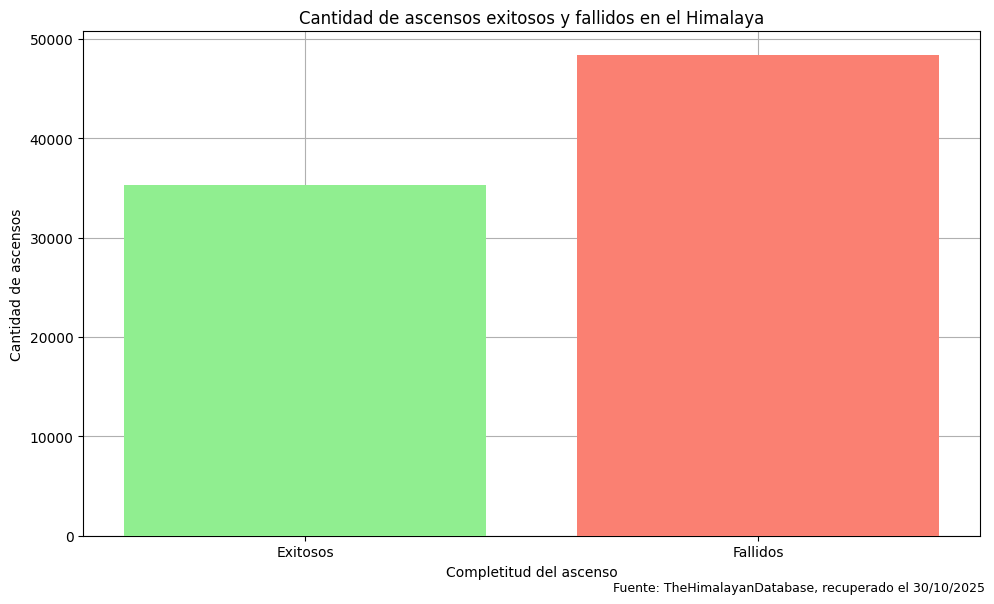

In [108]:
plt.figure(figsize=(10, 6))
plt.bar(['Exitosos', 'Fallidos'], [ascensos_exitosos, ascensos_fallidos], color=['lightgreen', 'salmon'], zorder=3)
plt.title('Cantidad de ascensos exitosos y fallidos en el Himalaya')
plt.xlabel('Completitud del ascenso')
plt.ylabel('Cantidad de ascensos')
plt.grid(True, zorder=0)
plt.figtext(
    0.99,
    0.00001,
    "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
    ha='right',
    va='bottom',
    fontsize=9
)
plt.tight_layout()
plt.show()

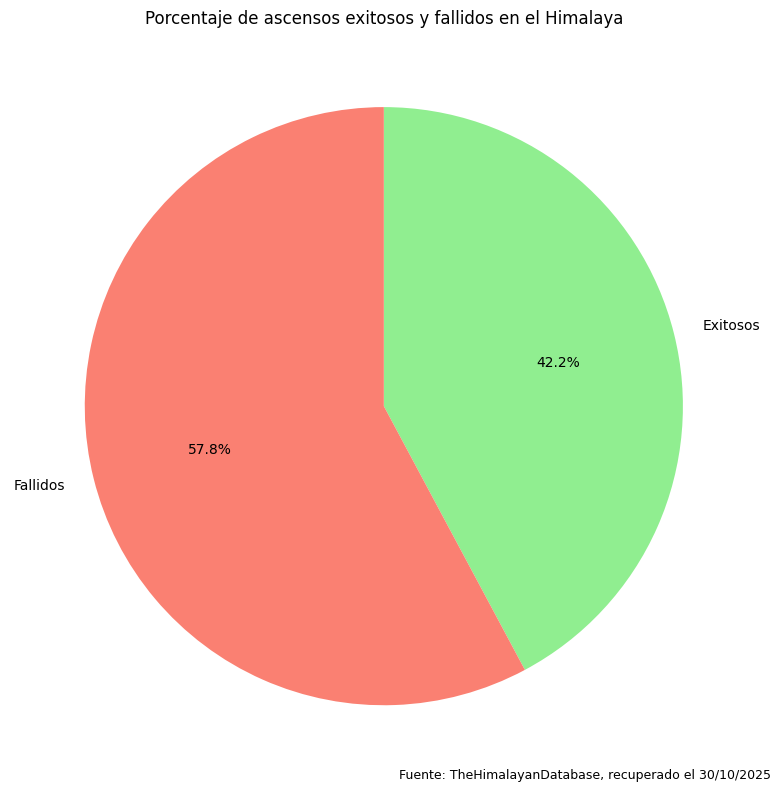

In [109]:
plt.figure(figsize=(8, 8))
labels = ['Exitosos', 'Fallidos']
sizes = [ascensos_exitosos, ascensos_fallidos]
colors = ['lightgreen', 'salmon']
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Porcentaje de ascensos exitosos y fallidos en el Himalaya')
plt.figtext(
    0.98, 0.02,
    "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
    ha='right', fontsize=9
)
plt.tight_layout()
plt.show()


b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

In [110]:
age_counts = clean_df['age'].value_counts()
edad_mas_comun = age_counts.idxmax()
cantidad_mas_comun = age_counts.max()
edad_menos_comun = age_counts.idxmin()
cantidad_menos_comun = age_counts.min()

print(f'Edad con más montañistas: {edad_mas_comun} ({cantidad_mas_comun} personas)')
print(f'Edad con menos montañistas: {edad_menos_comun} ({cantidad_menos_comun} personas)')

# Veamos las edades con más montañistas
age_counts.sort_values(ascending=False).head()

Edad con más montañistas: 34 (3233 personas)
Edad con menos montañistas: 81 (1 personas)


age
34    3233
33    3228
31    3214
30    3189
32    3187
Name: count, dtype: int64

In [111]:
# Veamos las edades con menos montañistas
age_counts.sort_values(ascending=True).head()

age
81    1
86    1
80    1
12    1
83    1
Name: count, dtype: int64

In [112]:
prom = clean_df['age'].mean()
prom

np.float64(38.29035769828927)

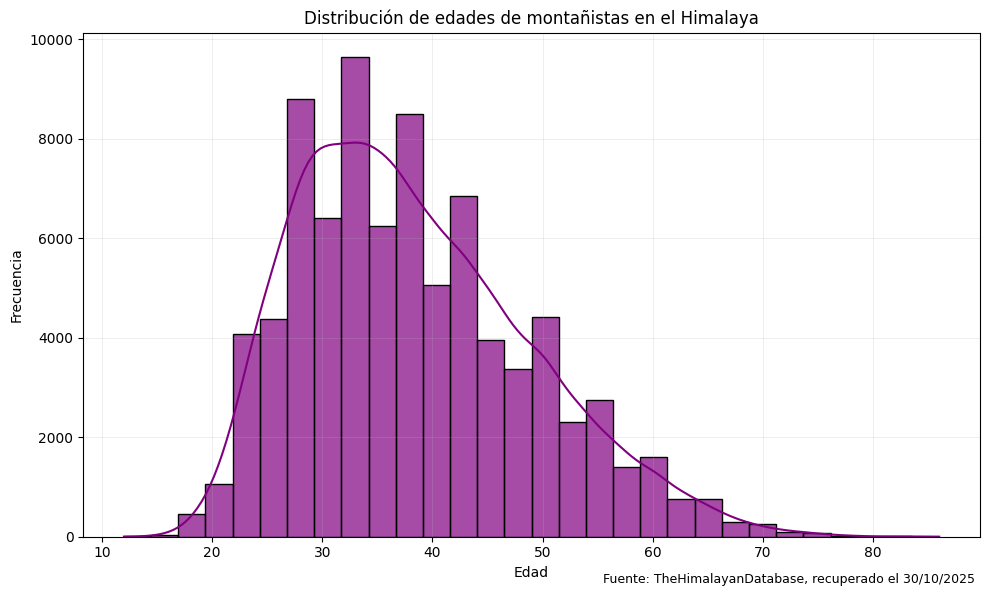

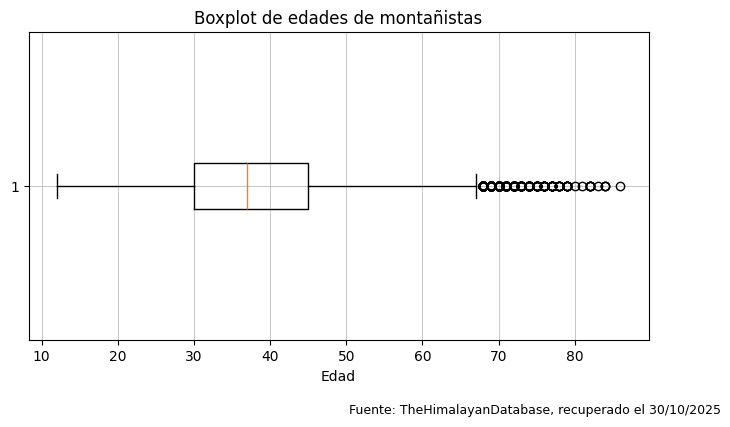

In [113]:
plt.figure(figsize=(10, 6))
sns.histplot(data=clean_df, x='age', bins=30, color='purple', 
             edgecolor='black', alpha=0.7, kde=True)
plt.title('Distribución de edades de montañistas en el Himalaya')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True, linewidth=0.5, zorder=0, alpha=0.3)
plt.figtext(0.98, 0.02,
            "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
            ha='right', fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(clean_df['age'], vert=False)
plt.title('Boxplot de edades de montañistas')
plt.xlabel('Edad')
plt.grid(True, linewidth=0.5, zorder=0)
plt.figtext(0.99, -0.05,
            "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
            ha='right', va='top', fontsize=9)
plt.show()


In [114]:
clean_df['age'].describe()

count    83590.000000
mean        38.290358
std         10.579652
min         12.000000
25%         30.000000
50%         37.000000
75%         45.000000
max         86.000000
Name: age, dtype: float64

La distribución de edades entre los montañistas que emprenden expediciones hacia el Himalaya revela un perfil demográfico: predomina los adultos, sobretodo fines de los 20's y todos los 30 años, loq ue se podría explicar porque es la edad donde se suele tener una combinación de buena codición física, experiencia y dinero. El dataset tiene una edad promedio de 38.3 años, con una mediana ligeramente inferior de 37 años, indicando una ligera concentración hacia las edades más jóvenes dentro del espectro general. La edad más frecuente entre los escaladores es 34 años, con 3233 personas concentradas en este punto específico, seguida muy de cerca por las edades de 33, 31, 30 y 32 años, todas superando los 3180 individuos (nuevamente, se solidifica el punto de que los adultos en los 30's son los más predominantes en la edad). La distribución presenta un rango intercuartílico que abarca desde los 30 hasta los 45 años, lo que significa que la mitad central de los montañistas se encuentra en este intervalo de 15 años. Esto vuelve al punto anterior, donde en estas edades se juntan los tres factores significativos para poder subir (condición física, experiencia, autonomía monetaria y personal).

En los extremos de la distribución se encuentran casos excepcionales: En el límite inferior, existe un montañista de 12 años, mientras que en el extremo superior se registra una persona de 86 años, acompañada por otros casos aislados en los 80, 81 y 83 años. Estos valores atípicos, aunque estadísticamente poco significativos en términos de volumen, demuestran que el montañismo himalayo no está estrictamente limitado por barreras etarias absolutas.

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

In [115]:
ascensos_por_estacion = clean_df['season'].value_counts()
ascensos_por_estacion

season
Spring    41291
Autumn    39529
Winter     2125
Summer      645
Name: count, dtype: int64

In [116]:
porcentaje_exito_estacion = clean_df.groupby('season')['msuccess'].mean() * 100
porcentaje_exito_estacion

season
Autumn    39.479876
Spring    45.983386
Summer    27.286822
Winter    23.105882
Name: msuccess, dtype: float64

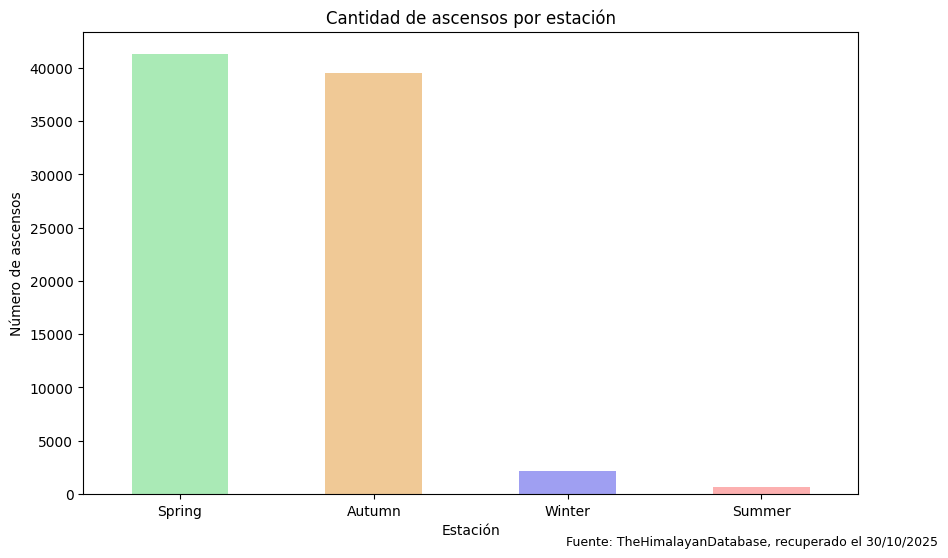

In [117]:
plt.figure(figsize=(10, 6))
clean_df['season'].value_counts().plot(kind='bar', color=["#AAEAB6", "#F0C996", "#9F9FF2", "#FCB0B0"])
plt.title('Cantidad de ascensos por estación')
plt.xlabel('Estación')
plt.ylabel('Número de ascensos')
plt.xticks(rotation=0)
plt.figtext(0.98, 0.02,
            "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
            ha='right', va='bottom', fontsize=9)
plt.show()

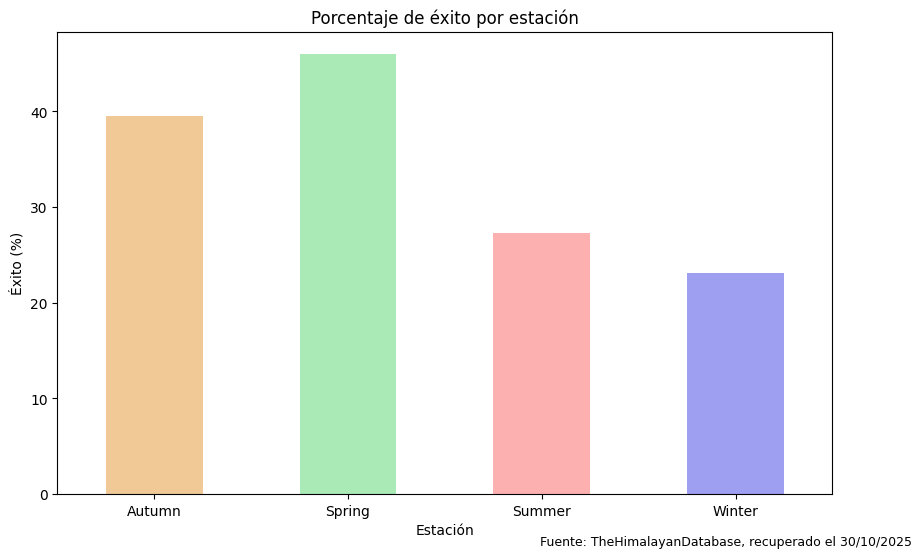

In [118]:
porcentaje_exito_estacion = clean_df.groupby('season')['msuccess'].mean() * 100

plt.figure(figsize=(10, 6))
porcentaje_exito_estacion.plot(kind='bar', color=["#F0C996", "#AAEAB6", "#FCB0B0", "#9F9FF2"])
plt.title('Porcentaje de éxito por estación')
plt.xlabel('Estación')
plt.ylabel('Éxito (%)')
plt.xticks(rotation=0)
plt.figtext(0.98, 0.02,
            "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
            ha='right', va='bottom', fontsize=9)
plt.show()


In [119]:
exitos_fallidos_por_estacion = clean_df.groupby('season')['msuccess'].value_counts().unstack().fillna(0)
exitos_fallidos_por_estacion.columns = ['fallidos', 'exitosos']
exitos_fallidos_por_estacion

,fallidos,exitosos
season,,
Autumn,23923,15606
Spring,22304,18987
Summer,469,176
Winter,1634,491


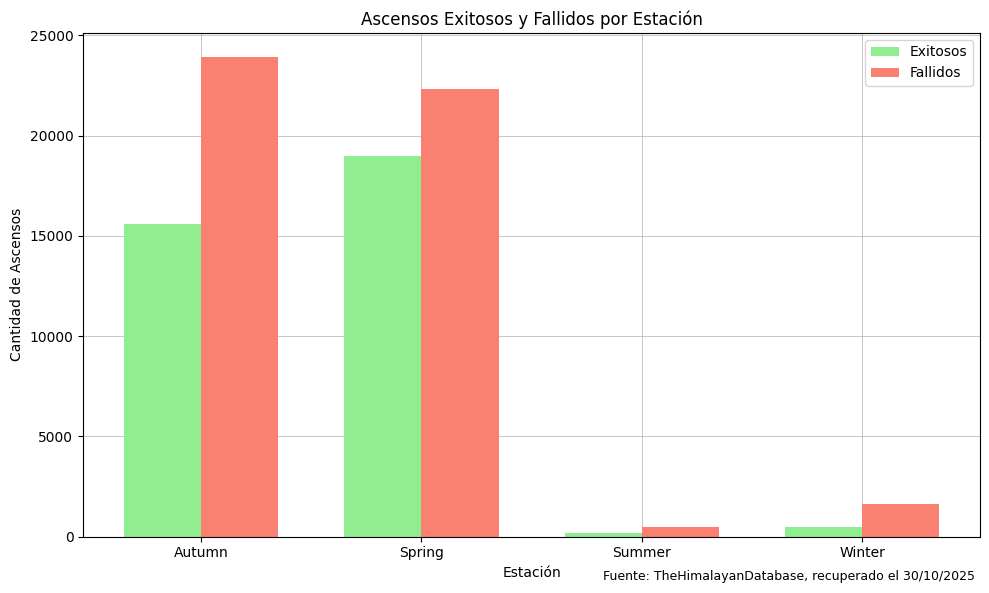

In [120]:
plt.figure(figsize=(10, 6))
x = np.arange(len(exitos_fallidos_por_estacion.index))
width = 0.35
plt.bar(x - width/2, exitos_fallidos_por_estacion['exitosos'], width, label='Exitosos', color='lightgreen')
plt.bar(x + width/2, exitos_fallidos_por_estacion['fallidos'], width, label='Fallidos', color='salmon')
plt.xticks(x, exitos_fallidos_por_estacion.index)
plt.title('Ascensos Exitosos y Fallidos por Estación')
plt.xlabel('Estación')
plt.ylabel('Cantidad de Ascensos')
plt.grid(True, zorder=0, linewidth=0.5)
plt.gca().set_axisbelow(True)
plt.legend()
plt.figtext(
    0.98, 0.02,
    "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
    ha='right',
    va='bottom',
    fontsize=9
)
plt.tight_layout()
plt.show()


Notamos, primero, que la cantidad de ascensos es mayormente significativa en los meses de primavera y otoño. Esto puede ser debido a la naturaleza misma del Himalaya: las montañas tienen de por sí un clima extremo, ir en temporadas de extremo frío o calor (invierno/verano) podría llegar a ser peligroso. También puede deberse a otras cosas, por ejemplo, tal vez en invierno prohiben muchas veces el ingreso por peligros de clima extremo, derrumbes, etc. Y en verano por la exposición dañina a los rayos UV. Si estos datos son decisión de las preferencias de los montañistas o imposiciones por las autoridades/guías necesitaría de otra base de datos y, por ende, otro estudio. 

La mayor cantidad de exitos lo tiene el mes de primavera, seguido de otoño, y el que menos éxito tiene es invierno. Aún así, ningún porcentaje llega al 50% de éxito, lo que nos habla de la dificultad de estas cadenas montañosas.

Finalmente, notamos que la cantidad de fracasos en cada caso es mayor, lo que tiene relación a lo que hablamos en el punto anterior, siendo otoño el mes que más diferencia hay entre casos exitosos v/s fallidos. En base a esto, podríamos llegar a concluir que el mejor mes para ir es primavera.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

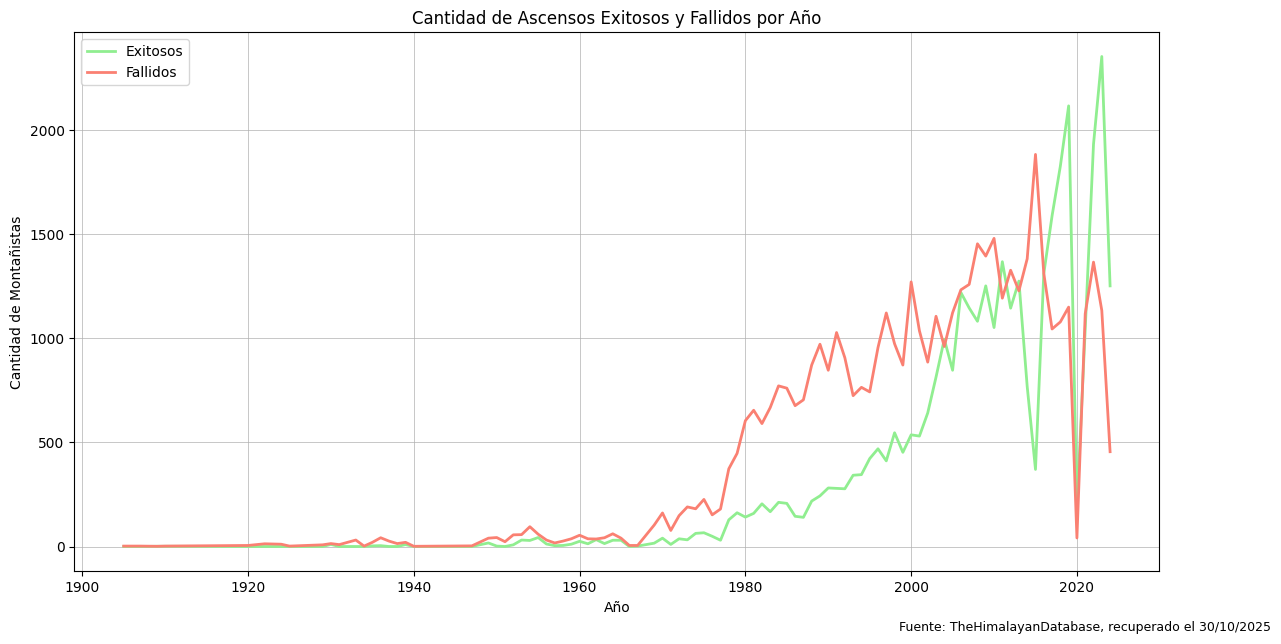

In [121]:
ascents_by_year = clean_df.groupby('year')['msuccess'].value_counts().unstack().fillna(0)
ascents_by_year.columns = ['Fallidos', 'Exitosos']
plt.figure(figsize=(14, 7))
plt.plot(
    ascents_by_year.index,
    ascents_by_year['Exitosos'],
    label='Exitosos',
    linewidth=2,
    color='lightgreen'
)
plt.plot(
    ascents_by_year.index,
    ascents_by_year['Fallidos'],
    label='Fallidos',
    linewidth=2,
    color='salmon'
)
plt.title('Cantidad de Ascensos Exitosos y Fallidos por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Montañistas')
plt.legend()
plt.grid(True, zorder=0, linewidth=0.5)
plt.gca().set_axisbelow(True)
plt.figtext(
    0.98, 0.02,
    "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
    ha='right',
    va='bottom',
    fontsize=9
)
plt.show()


Notemos que luego de la década del 70 hubo un "boom" de escalada, pues las gráficas comenzaron a subir significativamente, antes ambas líneas estaban muy por debajo de 250 incluso. Con el incremento de las subidas, se disparararon también los casos fallidos, creando una gran brecha hasta el año 2000. Podemos intentar explicar esto último desde dos perspectivas: al hacerse famoso por algún motivo, más gente no tan del nicho y aficionada comenzó a darle la oportunidad al montañismo, no logrando el objetivo por falta de preparación física; el otro, durante esa década se descubrió o se abrió al público una montaña más peligrosa que creó mayor flujo de turistas pero, al ser más peligrosa, tenía más probabilidades de fallar (por clima, estado físico, etc.). 

Ahora, fijemonos en cómo el gráfico cae en el 2020, la razón es más que obvia con nuestro propio conocimiento del presente: la pandemia que cerró todos estos lugares durante un tiempo, sobretodo la zona del Himalaya que era una "zona de gran concentración del virus" en ese tiempo. Además de lso complicados contextos políticos que surgieron en esos años en es elugar. Los años que seguíamos en pandemia podemos notar que hubo una gran baja de casos fallidos, esto s epuede deber a que, debido a la contingencia global, solo los más aficionados iban a arriesgarse y, por ende, subieron los casos de éxito por sobre el fallo.

Entonces, en resumen, la cantidad de ascensos en el tiempo parece tender a ir subiendo cada año, siendo en la mayoría de años la tasa de fracaso a la meta más predominante que la tasa de éxito exceptuando el período del 2020 (2019-2021). Sin embargo, para evaluar si este cambio representa un reajuste real en las tendencias del montañismo himalayo, sería necesario incorporar datos de años posteriores y observar si el equilibrio entre éxito y fracaso se mantiene o vuelve al comportamiento previo.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

C:\Users\isimo\AppData\Local\Temp\ipykernel_21620\3802753086.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_peaks['success_rate'] = filtered_peaks['total_success'] / filtered_peaks['total_exp']


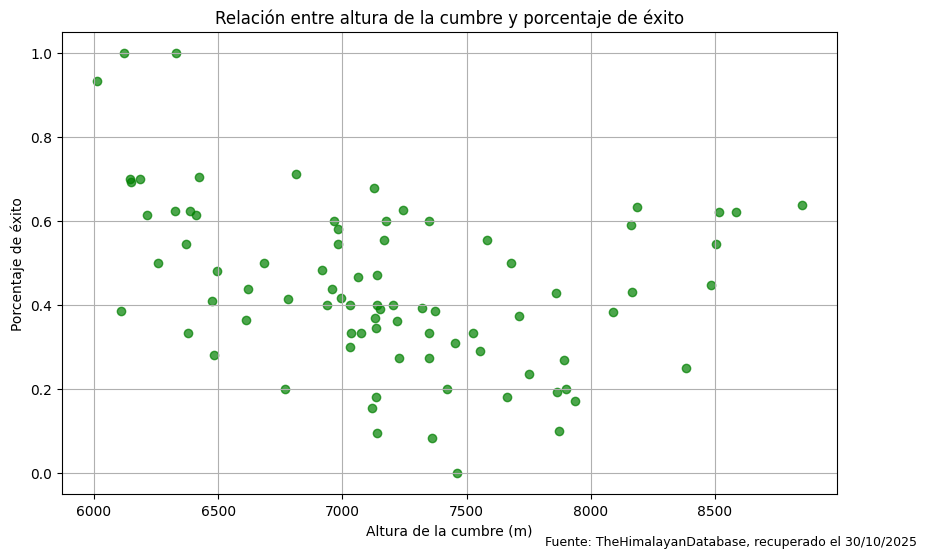

In [122]:
peak_stats = clean_df.groupby('peakid').agg(
    peak_height=('heightm', 'max'),
    total_success=('success_exp', 'max'),
    total_failed=('failed_exp', 'max')
)

peak_stats['total_exp'] = peak_stats['total_success'] + peak_stats['total_failed']
filtered_peaks = peak_stats[peak_stats['total_exp'] >= 10]

# Porcentaje de éxito
filtered_peaks['success_rate'] = filtered_peaks['total_success'] / filtered_peaks['total_exp']

plt.figure(figsize=(10, 6))
plt.scatter(
    filtered_peaks['peak_height'], 
    filtered_peaks['success_rate'], 
    alpha=0.7, 
    color='green'
    )
plt.title('Relación entre altura de la cumbre y porcentaje de éxito')
plt.xlabel('Altura de la cumbre (m)')
plt.ylabel('Porcentaje de éxito')
plt.grid(True)
plt.figtext(0.98, 0.02,
            "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
            ha='right', va='bottom', fontsize=9)
plt.show()


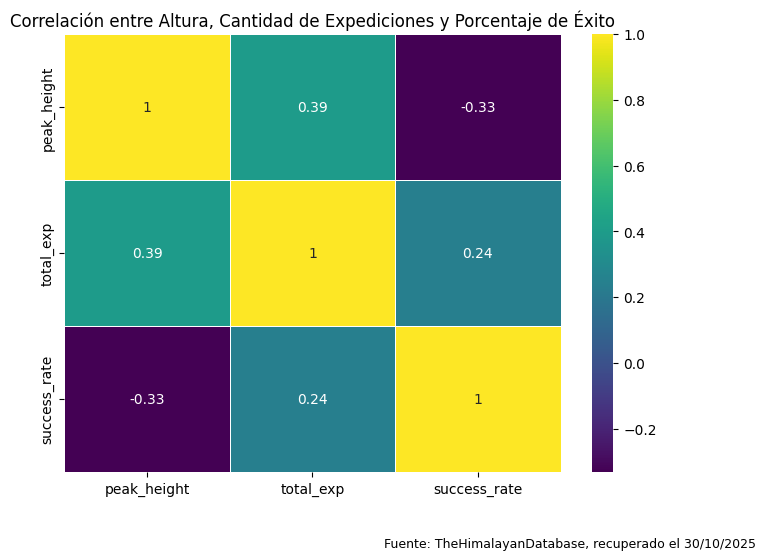

In [123]:
corr_df = filtered_peaks[['peak_height', 'total_exp', 'success_rate']]
corr_matrix = corr_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlación entre Altura, Cantidad de Expediciones y Porcentaje de Éxito')
plt.figtext(0.99, 0.02,
            "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
            ha='right', va='bottom', fontsize=9)
plt.subplots_adjust(bottom=0.15)
plt.show()

Los resultados muestran que no existe una relación lineal fuerte entre la altura de una cumbre y su porcentaje de éxito. El heatmap indica una correlación negativa moderada (~ −0.33) lo que sugiere que, en general, las montañas más altas tienden a tener un porcentaje ligeramente menor de éxito, pero esta relación está lejos de ser determinante. Mientras tanto, el scatterplot lo confirma visualmente: los puntos están muy dispersos y no siguen un patrón claro. Hay cumbres relativamente bajas con porcentajes de éxito bajos, y algunas cumbres altas con porcentajes de éxito sorprendentemente altos. Esto sugiere que la dificultad de una montaña no depende solo de la altura, sino también de factores como clima, rutas, experiencia requerida o peligros específicos.

Pero eso sí, es importante notar que en el scatterplot los puntos, si bien débiles y dispersos, tienden a bajar hasta 8000, luego se hace más complicada la lectura. Pero siempre los datos están algo dispersos.

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

*Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos:*

In [124]:
# Paso 1: definir X e y
variables_X = ['age', 'sex', 'citizen', 'season', 'heightm', 'year', 'success_exp', 'failed_exp']
X = clean_df[variables_X].copy()
y = clean_df['msuccess'].copy()

In [125]:
# 5.1 Codificación y normalización
print(X['sex'].value_counts())


sex
M    75044
F     8545
X        1
Name: count, dtype: int64


In [126]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83590 entries, 0 to 89088
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          83590 non-null  int64   
 1   sex          83590 non-null  category
 2   citizen      83590 non-null  object  
 3   season       83590 non-null  object  
 4   heightm      83590 non-null  int64   
 5   year         83590 non-null  int64   
 6   success_exp  83590 non-null  int64   
 7   failed_exp   83590 non-null  int64   
dtypes: category(1), int64(5), object(2)
memory usage: 5.2+ MB


In [127]:
# Al ser 'X' solo un dato, se eliminará para poder hacer un correcto mapeo a números en M y F
# solo se elimina X['sex'] == 'X'
mask = X['sex'] != 'X'
X = X[mask].copy()
y = y[mask]
X.info()
# Se vuelve a convertir en dtype string, ya que sino convertía todos los datos a NaN
X['sex'] = X['sex'].astype(str)

<class 'pandas.core.frame.DataFrame'>
Index: 83589 entries, 0 to 89088
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          83589 non-null  int64   
 1   sex          83589 non-null  category
 2   citizen      83589 non-null  object  
 3   season       83589 non-null  object  
 4   heightm      83589 non-null  int64   
 5   year         83589 non-null  int64   
 6   success_exp  83589 non-null  int64   
 7   failed_exp   83589 non-null  int64   
dtypes: category(1), int64(5), object(2)
memory usage: 5.2+ MB


In [128]:
# Se mapea F: 1, M: 0
X['sex'] = X['sex'].map({'M': 0, 'F': 1})
X.head()

,age,sex,citizen,season,heightm,year,success_exp,failed_exp
0,29,0,Australia,Spring,6814,2001,1123,453
1,33,0,Australia,Spring,6814,2001,1123,453
2,41,0,Australia,Spring,6814,2001,1123,453
3,35,0,Australia,Spring,6814,2001,1123,453
4,31,1,Australia,Spring,6814,2001,1123,453


In [129]:
# Asegúremonos que todas las variables sean números
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83589 entries, 0 to 89088
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          83589 non-null  int64 
 1   sex          83589 non-null  int64 
 2   citizen      83589 non-null  object
 3   season       83589 non-null  object
 4   heightm      83589 non-null  int64 
 5   year         83589 non-null  int64 
 6   success_exp  83589 non-null  int64 
 7   failed_exp   83589 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 5.7+ MB


In [130]:
# variables citizen y season: 

categorias_originales = {
    'citizen': list(X['citizen'].unique()),
    'season': list(X['season'].unique())
}
X_encoded = pd.get_dummies(X, columns=['citizen', 'season'], dtype=int)
columnas_one_hot = {
    'citizen': [col for col in X_encoded.columns if col.startswith('citizen_')],
    'season': [col for col in X_encoded.columns if col.startswith('season_')]
}

print("Categorías originales guardadas:")
print(categorias_originales)
print("\nColumnas one-hot creadas:")
print(columnas_one_hot)

Categorías originales guardadas:
{'citizen': ['Australia', 'USA', 'Russia', 'Spain', 'Japan', 'France', 'Czech Republic', 'UK', 'Germany', 'Sweden', 'Italy', 'Canada', 'Mexico', 'Austria', 'Switzerland', 'Nepal', 'China', 'Chile', 'S Korea', 'Hungary', 'Finland', 'New Zealand', 'S Africa', 'Denmark', 'Argentina', 'Peru', 'Turkey', 'USA/UK', 'India', 'Ecuador', 'Ireland', 'Guatemala', 'Kuwait', 'Brazil', 'Georgia', 'Singapore', 'Venezuela', 'Colombia', 'Luxembourg', 'Poland', 'Portugal', 'Kazakhstan', 'Iran', 'Ukraine', 'Netherlands', 'Belgium', 'Mongolia', 'Croatia', 'Slovenia', 'Norway', 'Liechtenstein', 'USA/Canada', 'Iceland', 'Greece', 'Bulgaria', 'Yugoslavia', 'Armenia', 'Estonia', 'Slovakia', 'Macedonia/Australia', 'San Marino', 'Serbia', 'Lithuania', 'Romania', 'Bhutan', 'Switzerland/UK', 'Belarus', 'France/Switzerland', 'Malaysia', 'Latvia', 'Lebanon', 'Kyrgyz Republic', 'Switzerland/USA', 'Switzerland/France', 'Uzbekistan', 'Malta', 'Cyprus', 'Taiwan', 'Israel', 'Singapore/Mal

In [131]:
X_encoded.head()

,age,sex,heightm,year,success_exp,failed_exp,citizen_Afghanistan,citizen_Afghanistan/USA,citizen_Albania,citizen_Algeria,...,citizen_Uzbekistan,citizen_Venezuela,citizen_Vietnam,citizen_W Germany,citizen_W Germany/Iran,citizen_Yugoslavia,season_Autumn,season_Spring,season_Summer,season_Winter
0,29,0,6814,2001,1123,453,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,33,0,6814,2001,1123,453,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,41,0,6814,2001,1123,453,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,35,0,6814,2001,1123,453,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,31,1,6814,2001,1123,453,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [132]:
# Verificar que solo hay 0's y 1's en las columnas correspondientes a citizen y season
columnas_one_hot = [col for col in X_encoded.columns if col.startswith(('citizen_', 'season_'))]
for col in columnas_one_hot:
    valores_unicos = sorted(X_encoded[col].unique())
    print(f"{col}: {valores_unicos}")

citizen_Afghanistan: [np.int64(0), np.int64(1)]
citizen_Afghanistan/USA: [np.int64(0), np.int64(1)]
citizen_Albania: [np.int64(0), np.int64(1)]
citizen_Algeria: [np.int64(0), np.int64(1)]
citizen_Andorra: [np.int64(0), np.int64(1)]
citizen_Argentina: [np.int64(0), np.int64(1)]
citizen_Argentina/Canada: [np.int64(0), np.int64(1)]
citizen_Armenia: [np.int64(0), np.int64(1)]
citizen_Australia: [np.int64(0), np.int64(1)]
citizen_Australia/Greece: [np.int64(0), np.int64(1)]
citizen_Australia/Ireland: [np.int64(0), np.int64(1)]
citizen_Australia/New Zealand: [np.int64(0), np.int64(1)]
citizen_Australia/S Africa: [np.int64(0), np.int64(1)]
citizen_Australia/Sweden: [np.int64(0), np.int64(1)]
citizen_Australia/UK: [np.int64(0), np.int64(1)]
citizen_Australia/USA: [np.int64(0), np.int64(1)]
citizen_Austria: [np.int64(0), np.int64(1)]
citizen_Austria/Brazil: [np.int64(0), np.int64(1)]
citizen_Azerbaijan: [np.int64(0), np.int64(1)]
citizen_Azerbaijan/Russia: [np.int64(0), np.int64(1)]
citizen_Bah

In [133]:
X = X_encoded
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83589 entries, 0 to 89088
Columns: 258 entries, age to season_Winter
dtypes: int64(258)
memory usage: 165.2 MB


*Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30:*

In [134]:
# Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,  
    random_state=77, 
    stratify=y 
)

*Normalice sus matrices de atributos. Justifique su método de normalización:*

In [135]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Justificación del método *StandardScaler*: Se ha seleccionado este método debido a las diferencias de escala de las variables entre sí (age en años, heightm en metros, year en cientos, citizen [todas sus columnas], season [todas sus columnas] y sex en binario...), y existen modelos altamente sensibles a esta diferencia de escala, cosa que otras fromas de normalización no manejan con magnitudes distintas entre columnas. Por lo tanto, se utilizó StandardScaler para asegurar que todas las variables contribuyan proporcionalmente al modelo y evitar sesgos debidos a la escala.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

In [136]:
# 1. KNN
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train_scaled, y_train)

,n_neighbors,7
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [137]:
# 2. Árbol de decisión
arbol = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=50,
    random_state=42
)
arbol.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,50
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [138]:
# 3. Regresión logística
relog = LogisticRegression(
    max_iter=500,
    penalty='l2',
    solver='lbfgs'
)
relog.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [139]:
# 4. Random forest
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_split=50,
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,10
,min_samples_split,50
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Notar que en los modelos [árbol de decisión, random forest] no se ha utilizado X_scaled mientras que en [kNN, regresión logística] sí. Esto es debido a que estos modelos no se benefician del escalado y mantener las unidades originales mejora su interpretabilidad.


° KNN:
Accuracy: 0.7166327710651195
Precisión: 0.6742621963461153
Recall: 0.6349971639251276
Matriz de confusión:
 [[11254  3245]
 [ 3861  6717]]


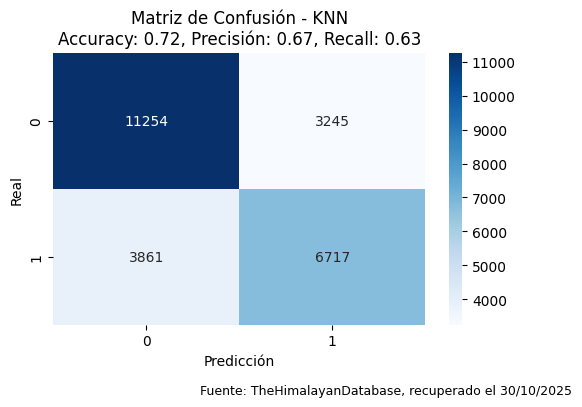


° Árbol de Decisión:
Accuracy: 0.7247677154364557
Precisión: 0.6953241232731137
Recall: 0.6185479296653431
Matriz de confusión:
 [[11632  2867]
 [ 4035  6543]]


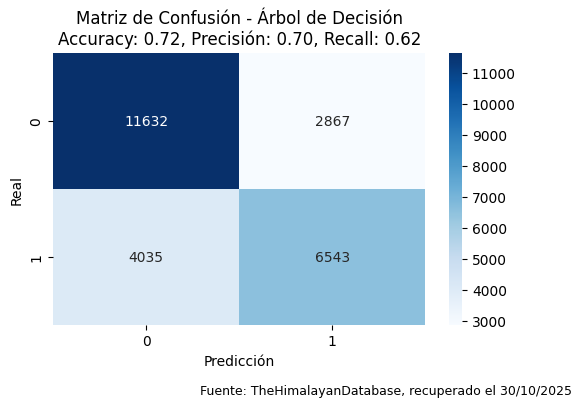


° Regresión Logística:
Accuracy: 0.6963751644933605
Precisión: 0.6780394041326285
Recall: 0.5335602193231235
Matriz de confusión:
 [[11819  2680]
 [ 4934  5644]]


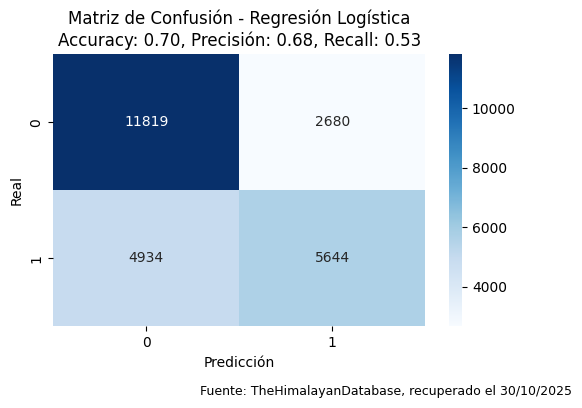


° Random Forest:
Accuracy: 0.7116880009570523
Precisión: 0.75
Recall: 0.474758933635848
Matriz de confusión:
 [[12825  1674]
 [ 5556  5022]]


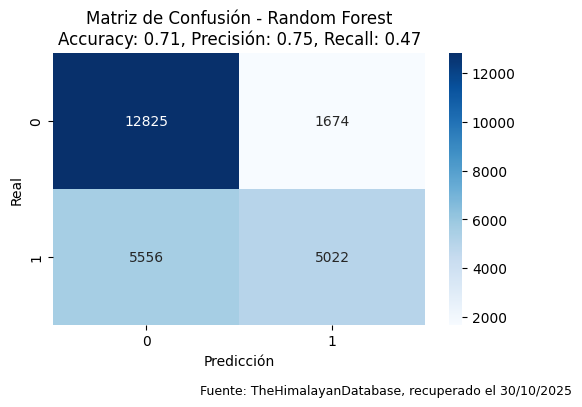

In [147]:
# Evaluación de modelos:
modelos = {
    'KNN': knn,
    'Árbol de Decisión': arbol,
    'Regresión Logística': relog,
    'Random Forest': rf
}
for nombre, modelo in modelos.items():
    if nombre in ['KNN', 'Regresión Logística']:
        y_pred = modelo.predict(X_test_scaled)
    else:
        y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f'\n° {nombre}:')
    print('Accuracy:', acc)
    print('Precisión:', prec)
    print('Recall:', rec)
    print('Matriz de confusión:\n', cm)
    
    # Graficar matriz de confusión
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}\nAccuracy: {acc:.2f}, Precisión: {prec:.2f}, Recall: {rec:.2f}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.subplots_adjust(bottom=0.20)
    plt.figtext(0.99, 0.02,
            "Fuente: TheHimalayanDatabase, recuperado el 30/10/2025",
            ha='right', va='bottom', fontsize=9)
    plt.show()

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 

Al analizar los resultados de los cuatro modelos, se pueden observar varias tendencias interesantes en cuanto a su desempeño. 

En términos de exactitud general (accuracy), el Árbol de Decisión lidera con 0.725, seguido de cerca por KNN y Random Forest, mientras que la Regresión Logística muestra la menor exactitud con 0.696. De todas formas, ninguno pasa el 80% de precisión ni baja del 50%. Esto indica que, globalmente, el Árbol de Decisión es ligeramente más eficaz al clasificar correctamente tanto la clase positiva como la negativa, aunque las diferencias con KNN y Random Forest no son drásticas.

Si nos fijamos en la precisión, Random Forest se destaca con 0.75, lo que significa que cuando este modelo predice los positivos, lo hace correctamente la mayor parte de las veces. Esto contrasta con los demás modelos, que tienen precisiones más cercanas entre sí, alrededor de 0.67-0.70. Sin embargo, la alta precisión de Random Forest viene acompañada de un bajo recall (0.475), lo que indica que muchos casos positivos reales no son detectados. En otras palabras, Random Forest es conservador al predecir positivos, priorizando evitar falsos positivos pero perdiendo muchos verdaderos positivos.

KNN y Árbol de Decisión muestran un mayor equilibrio entre precisión y recall, con valores de recall de 0.635 y 0.619, respectivamente. Esto sugiere que estos modelos capturan una mayor proporción de positivos reales, aunque al costo de tener un poco más de falsos positivos que Random Forest. La Regresión Logística, en cambio, tiene un recall relativamente bajo (0.534), lo que indica que también pierde muchos casos positivos, aunque su precisión es moderada.

Finalmente, al observar las matrices de confusión, se confirma esta tendencia: Random Forest presenta el mayor número de falsos negativos (5556), mientras que KNN y Árbol de Decisión muestran un balance más equilibrado entre falsos positivos y negativos. Esto demuestra que, aunque la exactitud global es un indicador útil, es importante considerar precisión y recall para entender cómo cada modelo maneja la predicción de la clase positiva, especialmente si el objetivo es minimizar la pérdida de positivos reales o reducir los falsos positivos según el contexto del problema.

* ¿Fue posible construir un predictor efectivo? Justique.

Sí y no. 

Fue posible construir un predictor _relativamente_ efectivo, pero con matices importantes. Los modelos evaluados alcanzan accuracies entre 0.696 y 0.725, lo que indica que, en términos generales, más del 69% de las predicciones son correctas. Esto demuestra que los modelos capturan cierta relación entre las variables de entrada y la variable objetivo, por lo que sí existe poder predictivo. Sin embargo, la efectividad depende del objetivo específico de predicción, por ejemplo, Random Forest tiene una alta precisión (0.75) pero un bajo recall (0.475), lo que significa que predice con confianza los casos positivos que identifica, pero falla en capturar muchos positivos reales. Por el contrario, KNN y Árbol de Decisión presentan un mejor equilibrio entre precisión y recall, logrando capturar más casos positivos, aunque con más falsos positivos.

Podemos decir que los modelos funcionan mejor que un predictor aleatorio, pero ninguno es perfecto: cada uno tiene un compromiso entre evitar falsos positivos y detectar todos los positivos reales. Por ello, su efectividad depende del contexto: si es más importante no perder positivos, KNN o Árbol de Decisión serían preferibles; si es más importante evitar falsos positivos, Random Forest es más adecuado. En general, sí se construyó un predictor funcional, pero todavía habría espacio para optimización y ajuste según la métrica que se priorice.

En resumen, como todo en ciencia de datos, depende mucho del contexto acerca de qué se quiere hacer, qué se quiere lograr. Sin embargo, si se desea un mejor predictor efectivo, se necesiten probeblemente modelos más avanzados, utilizando hiperparámetros optimizados para poder hacer una predicción más exitosa.